In [1]:
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Loading Processed Dataset
bundle = joblib.load("../backend/models/bankloan/bankloan_data_bundle.pkl")

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]

print("Success!")
print(f"X_train size: {X_train.shape}, X_test size: {X_test.shape}")

Success!
X_train size: (4000, 5), X_test size: (1000, 5)


In [2]:
# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=250,
    min_samples_split=4,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
)

In [3]:
# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="accuracy")

print("K-Fold (K=5) Validation Scores:", cv_scores)
print("Average CV Validation: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

K-Fold (K=5) Validation Scores: [0.97375 0.975   0.9675  0.9675  0.965  ]
Average CV Validation: 0.9698 (+/- 0.0078)


In [4]:
# Training the Model
rf_model.fit(X_train, y_train)
print("\nModel is trained!")


Model is trained!


In [5]:
# Train Set Performance (For Overfitting)
y_train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("=" * 40)
print("          TRAIN SET PERFORMANCE          ")
print("=" * 40)
print(f"Train Accuracy: {train_accuracy:.4f}\n")
print("Train Classification (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred))

# Test Set Performance
y_test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 40)
print("          TEST SET PERFORMANCE           ")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy:.4f}\n")
print("Test Classification (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred))

          TRAIN SET PERFORMANCE          
Train Accuracy: 0.9802

Train Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3616
           1       0.97      0.82      0.89       384

    accuracy                           0.98      4000
   macro avg       0.97      0.91      0.94      4000
weighted avg       0.98      0.98      0.98      4000

          TEST SET PERFORMANCE           
Test Accuracy: 0.9740

Test Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       904
           1       0.90      0.82      0.86        96

    accuracy                           0.97      1000
   macro avg       0.94      0.91      0.92      1000
weighted avg       0.97      0.97      0.97      1000



In [6]:
# Saving the Model
joblib.dump(rf_model, "../backend/models/bankloan/random_forest_model.pkl")
print("Trained model is successfully saved!")

Trained model is successfully saved!


--- Feature Importance Scores ---
      Feature  Importance
0      Income    0.372538
4   Education    0.310906
1       CCAvg    0.192013
2  CD.Account    0.084610
3    Mortgage    0.039933


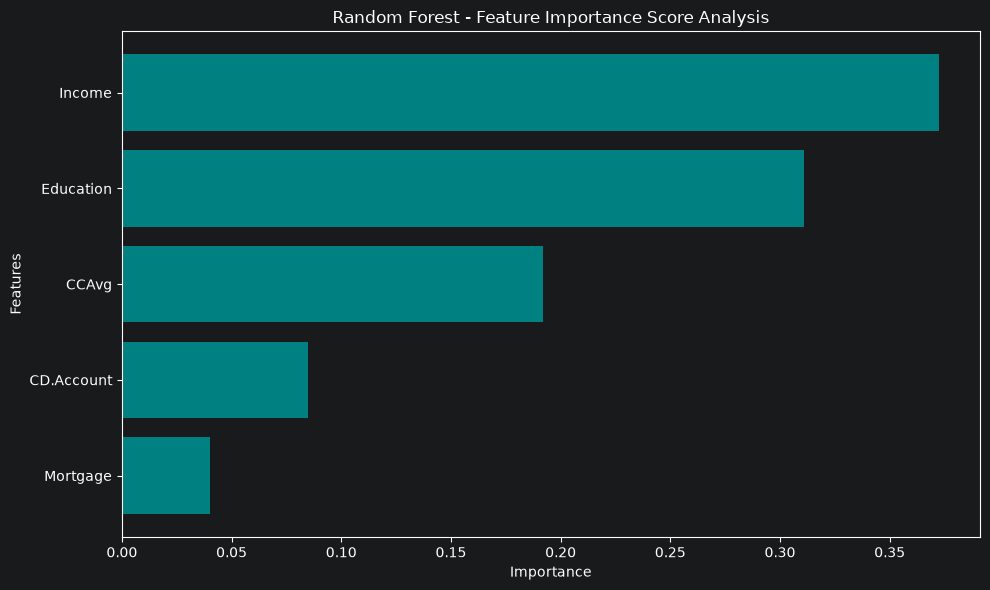

In [7]:
# 1. Feature importance
importances = rf_model.feature_importances_
feature_names = (
    X_train.columns
)

# 2. Converting to DataFrame
feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
)
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

print("--- Feature Importance Scores ---")
print(feature_imp_df)

# 3. Virtualization
plt.figure(figsize=(10, 6))
plt.barh(
    feature_imp_df["Feature"], feature_imp_df["Importance"], color="teal"
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest - Feature Importance Score Analysis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# 1. Read the original raw CSV file directly
df = pd.read_csv("../datasets/bankloan.csv")

# 2. Split into X and y
X = df.drop("Personal.Loan", axis=1)
y = df["Personal.Loan"]

# 3. Split into Train-Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Raw data loaded and split!")

# 4. Train the model with raw data
rf_raw_model = RandomForestClassifier(
    n_estimators=250,
    min_samples_split=4,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
)
rf_raw_model.fit(X_train_raw, y_train)

# 5. Train Set Performance For Raw Model
y_train_pred_raw = rf_raw_model.predict(X_train_raw)
train_accuracy_raw = accuracy_score(y_train, y_train_pred_raw)

print("=" * 40)
print("         RAW DATA - TRAIN SET PERFORMANCE          ")
print("=" * 40)
print(f"Train Accuracy: {train_accuracy_raw:.4f}\n")
print("Train Classification Report (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred_raw))

# 6. Test Set Performance For Raw Model (Real success)
y_test_pred_raw = rf_raw_model.predict(X_test_raw)
test_accuracy_raw = accuracy_score(y_test, y_test_pred_raw)

print("=" * 40)
print("         RAW DATA - TEST SET PERFORMANCE           ")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy_raw:.4f}\n")
print("Test Classification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred_raw))

Raw data loaded and split!
         RAW DATA - TRAIN SET PERFORMANCE          
Train Accuracy: 0.9942

Train Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3616
           1       1.00      0.94      0.97       384

    accuracy                           0.99      4000
   macro avg       1.00      0.97      0.98      4000
weighted avg       0.99      0.99      0.99      4000

         RAW DATA - TEST SET PERFORMANCE           
Test Accuracy: 0.9900

Test Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       904
           1       0.95      0.95      0.95        96

    accuracy                           0.99      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000

